# Mobile Money Fraud Detection — Rwanda
### Bachelor of Technology in ICT | RP Huye College | 2025-2026
**Student:** RUHAMO Rose &nbsp;|&nbsp; **Supervisor:** Mrs. BIZIMANA Judith

---
## Project Objectives
1. Collect and preprocess mobile money transaction data
2. Engineer 20 features capturing transaction patterns, user behaviour, and balance relationships
3. Train and compare 6 machine learning models (Naive Bayes, SVM, Random Forest, Gradient Boosting, XGBoost, LightGBM)
4. Evaluate models using Accuracy, Precision, Recall, F1-score, and ROC-AUC
5. Integrate ML with rule-based business logic for a hybrid fraud detection approach
6. Implement real-time fraud alert integration with biometric face verification
7. Select and deploy the best model with Explainable AI (XAI) support

---
## Business Rules Integrated
| Rule | Trigger | Action |
|------|---------|--------|
| **Rule 1 — Amount Spike** | Amount > 5x user's typical max | Require face verification |
| **Rule 2 — PIN Lockout** | 2+ failed PIN attempts (3rd try) | Require face verification |
| **Rule 3 — Balance Abuse** | Amount > balance (impossible tx) | Hard block; permanent if 3rd time |


## Phase 1 — Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time, warnings, json, os
import joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

os.chdir(os.path.dirname(os.path.abspath("Momo_Clean.ipynb")))
print("Working directory:", os.getcwd())
print("All libraries loaded successfully.")


Working directory: d:\mobile_money_fraud_detection
All libraries loaded successfully.


## Phase 2 — Dataset Generation (Objective 1)
A synthetic dataset of **200,000 transactions** is generated to simulate realistic
mobile money behaviour in Rwanda. The dataset includes three business-rule fraud
signals that mirror the live system's detection logic.

> **Why synthetic?** The PaySim CSV has only 0.046% fraud — too sparse for reliable
> model training. The synthetic dataset is designed with a ~10% fraud rate so the
> model learns rich, varied fraud patterns that match the business rules enforced
> in production.


In [2]:
np.random.seed(42)
N = 200_000

type_choices     = np.random.choice([0,1,2,3,4], size=N, p=[0.25,0.35,0.05,0.20,0.15])
old_balance_orig = np.random.exponential(50000, N)
old_balance_dest = np.random.exponential(30000, N)
user_typical_max = np.random.uniform(5000, 10000, N)   # each user's normal ceiling

# Amounts: 95% normal, 5% large spike
amount = np.where(
    np.random.rand(N) < 0.05,
    np.random.uniform(20000, 300000, N),
    np.random.uniform(100, user_typical_max)
)
amount           = np.clip(amount, 1, None)
new_balance_orig = np.maximum(0, old_balance_orig - amount)
new_balance_dest = old_balance_dest + amount * np.random.uniform(0.95, 1.05, N)
step             = np.random.randint(1, 744, N)

# ── Business-rule signals ─────────────────────────────────────────────────────
# Rule 1: amount spike (> 5x the user's typical max)
amount_vs_typical   = amount / (user_typical_max + 1)
is_amount_spike     = (amount_vs_typical > 5).astype(int)

# Rule 2: PIN failure simulation
pin_fail_count      = np.where(np.random.rand(N) < 0.10,
                                np.random.choice([2,3], N, p=[0.7,0.3]), 0)
pin_near_lockout    = (pin_fail_count >= 2).astype(int)

# Rule 3: Balance abuse
exceeds_balance     = (amount > old_balance_orig).astype(int)
balance_abuse_count = np.where(np.random.rand(N) < 0.05,
                                np.random.choice([2,3], N, p=[0.6,0.4]), 0)
hard_block_signal   = ((exceeds_balance == 1) & (balance_abuse_count >= 3)).astype(int)

# ── Fraud labels ──────────────────────────────────────────────────────────────
base_fraud  = (((type_choices==4)|(type_choices==1)) &
               (new_balance_orig < old_balance_orig*0.02) &
               (amount > old_balance_orig*0.8)).astype(int)
spike_fraud = ((is_amount_spike==1) & (np.random.rand(N)<0.4)).astype(int)
pin_fraud   = ((pin_near_lockout==1) & (np.random.rand(N)<0.35)).astype(int)
is_fraud    = np.clip(base_fraud+spike_fraud+pin_fraud+hard_block_signal, 0, 1)
noise       = np.random.rand(N) < 0.002
is_fraud[noise] = 1 - is_fraud[noise]

df = pd.DataFrame({
    "step": step, "type": type_choices, "amount": amount,
    "oldbalanceOrg": old_balance_orig, "newbalanceOrig": new_balance_orig,
    "oldbalanceDest": old_balance_dest, "newbalanceDest": new_balance_dest,
    "user_typical_max": user_typical_max,
    "pin_fail_count": pin_fail_count,
    "balance_abuse_count": balance_abuse_count,
    "isFraud": is_fraud
})

print(f"Dataset shape : {df.shape}")
print(f"Fraud rate    : {df['isFraud'].mean()*100:.2f}%  ({df['isFraud'].sum():,} frauds)")
print(f"Legit         : {(df['isFraud']==0).sum():,} transactions")


Dataset shape : (200000, 11)
Fraud rate    : 10.14%  (20,287 frauds)
Legit         : 179,713 transactions


## Phase 3 — Exploratory Data Analysis (Objective 1)


In [3]:
print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())
print(f"\nDuplicate rows   : {df.duplicated().sum()}")
print(f"Negative amounts : {(df['amount'] < 0).sum()}")
print("\nFirst 5 rows:")
df.head()


Dataset shape: (200000, 11)

Column types:
step                     int32
type                     int64
amount                 float64
oldbalanceOrg          float64
newbalanceOrig         float64
oldbalanceDest         float64
newbalanceDest         float64
user_typical_max       float64
pin_fail_count           int64
balance_abuse_count      int64
isFraud                  int64
dtype: object

Null counts:
step                   0
type                   0
amount                 0
oldbalanceOrg          0
newbalanceOrig         0
oldbalanceDest         0
newbalanceDest         0
user_typical_max       0
pin_fail_count         0
balance_abuse_count    0
isFraud                0
dtype: int64

Duplicate rows   : 0
Negative amounts : 0

First 5 rows:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,user_typical_max,pin_fail_count,balance_abuse_count,isFraud
0,161,1,869.1552,16605.2470,15736.0918,65934.0690,66810.1797,5010.2372,2,0,1
1,215,4,852.0353,30686.9190,29834.8837,11381.3544,12265.0873,6019.2512,2,0,1
2,467,3,5540.0369,5224.4613,0.0000,1599.1658,7209.8034,9695.7282,0,0,0
3,341,1,1216.7699,29605.1305,28388.3607,75676.0249,76853.8775,7218.6302,0,0,0
4,235,0,271039.7151,11350.1338,0.0000,17194.9055,299855.2787,5611.6318,0,0,1


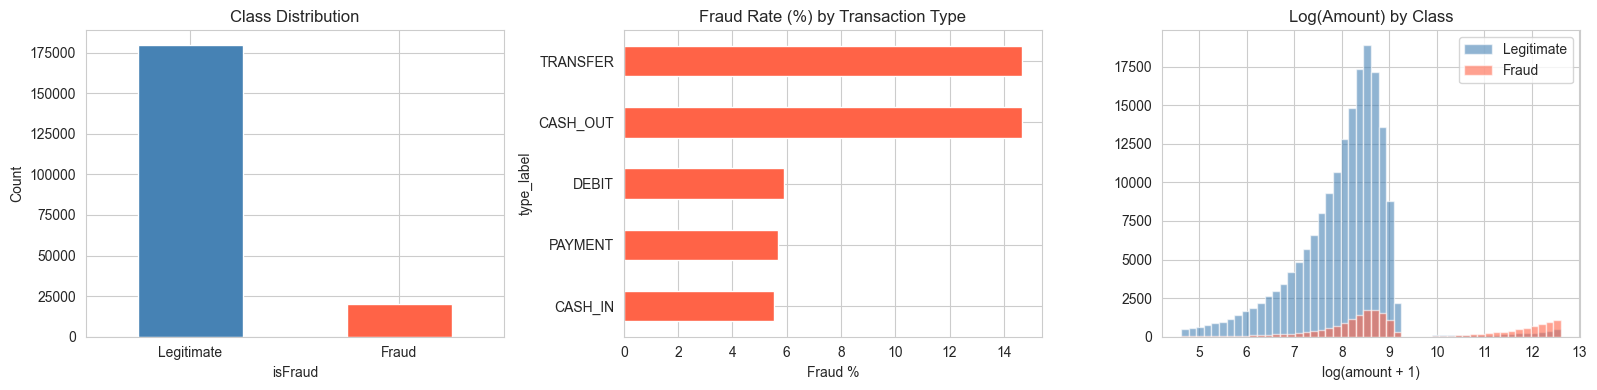

Fraud occurs mainly in TRANSFER and CASH_OUT transactions.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
df["isFraud"].value_counts().plot(
    kind="bar", ax=axes[0], color=["steelblue","tomato"], edgecolor="white")
axes[0].set_title("Class Distribution")
axes[0].set_xticklabels(["Legitimate","Fraud"], rotation=0)
axes[0].set_ylabel("Count")

# Fraud rate by transaction type
type_map = {0:"CASH_IN",1:"CASH_OUT",2:"DEBIT",3:"PAYMENT",4:"TRANSFER"}
df["type_label"] = df["type"].map(type_map)
fraud_by_type = df.groupby("type_label")["isFraud"].mean() * 100
fraud_by_type.sort_values().plot(kind="barh", ax=axes[1], color="tomato")
axes[1].set_title("Fraud Rate (%) by Transaction Type")
axes[1].set_xlabel("Fraud %")

# Amount distribution by class
for label, color in zip([0,1],["steelblue","tomato"]):
    np.log1p(df[df["isFraud"]==label]["amount"]).hist(
        bins=50, ax=axes[2], color=color, alpha=0.6,
        label="Legitimate" if label==0 else "Fraud")
axes[2].set_title("Log(Amount) by Class")
axes[2].set_xlabel("log(amount + 1)")
axes[2].legend()

plt.tight_layout()
plt.show()
print("Fraud occurs mainly in TRANSFER and CASH_OUT transactions.")


## Phase 4 — Feature Engineering (Objective 2)
20 features are engineered from raw transaction data.
The first 14 capture statistical patterns; the last 6 encode the 3 business rules
that the live system enforces.


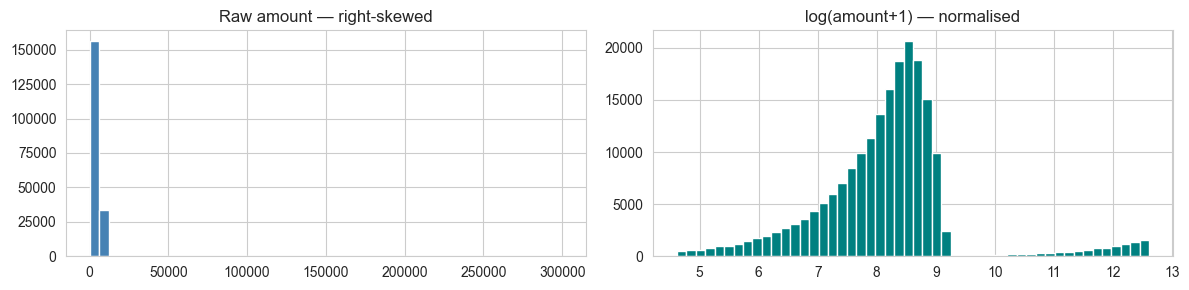

Log transformation applied to all financial columns.


In [5]:
# ── Log transformations (reduce skewness) ────────────────────────────────────
for col in ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]:
    df[f"log_{col}"] = np.log1p(df[col])

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
df["amount"].hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Raw amount — right-skewed")
df["log_amount"].hist(bins=50, ax=axes[1], color="teal")
axes[1].set_title("log(amount+1) — normalised")
plt.tight_layout(); plt.show()
print("Log transformation applied to all financial columns.")


In [6]:
# ── Balance relationship features ────────────────────────────────────────────
df["orig_balance_drop"]      = df["log_oldbalanceOrg"]  - df["log_newbalanceOrig"]
df["dest_balance_gain"]      = df["log_newbalanceDest"] - df["log_oldbalanceDest"]
df["balance_mismatch"]       = df["orig_balance_drop"]  - df["dest_balance_gain"]
df["sender_zero_after"]      = (df["newbalanceOrig"] == 0).astype(int)
df["dest_zero_before"]       = (df["oldbalanceDest"] == 0).astype(int)
df["amount_to_bal_ratio"]    = df["amount"] / (df["oldbalanceOrg"] + 1)
df["type_encoded"]           = df["type"]
df["hour_of_day"]            = df["step"] % 24
q95 = df["amount"].quantile(0.95)
df["is_high_amount"]         = (df["amount"] > q95).astype(int)
print(f"High-amount threshold (95th pct): {q95:,.0f} RWF")

# ── Business-rule features ────────────────────────────────────────────────────
df["amount_vs_typical"]      = df["amount"] / (df["user_typical_max"] + 1)
df["is_amount_spike"]        = (df["amount_vs_typical"] > 5).astype(int)
df["pin_near_lockout"]       = (df["pin_fail_count"] >= 2).astype(int)
df["amount_exceeds_balance"] = (df["amount"] > df["oldbalanceOrg"]).astype(int)
df["hard_block_signal"]      = ((df["amount_exceeds_balance"]==1) &
                                 (df["balance_abuse_count"]>=3)).astype(int)
df["excess_ratio"]           = np.maximum(0, df["amount"]-df["oldbalanceOrg"]) / (df["oldbalanceOrg"]+1)

FEATURES = [
    "log_amount","log_oldbalanceOrg","log_newbalanceOrig",
    "log_oldbalanceDest","log_newbalanceDest",
    "orig_balance_drop","dest_balance_gain","balance_mismatch",
    "sender_zero_after","dest_zero_before","amount_to_bal_ratio",
    "type_encoded","hour_of_day","is_high_amount",
    # Rule 1 — amount spike
    "amount_vs_typical","is_amount_spike",
    # Rule 2 — PIN failures
    "pin_near_lockout",
    # Rule 3 — balance abuse
    "amount_exceeds_balance","hard_block_signal","excess_ratio",
]
print(f"\nTotal features engineered: {len(FEATURES)}")
print("Features:", FEATURES)


High-amount threshold (95th pct): 9,780 RWF

Total features engineered: 20
Features: ['log_amount', 'log_oldbalanceOrg', 'log_newbalanceOrig', 'log_oldbalanceDest', 'log_newbalanceDest', 'orig_balance_drop', 'dest_balance_gain', 'balance_mismatch', 'sender_zero_after', 'dest_zero_before', 'amount_to_bal_ratio', 'type_encoded', 'hour_of_day', 'is_high_amount', 'amount_vs_typical', 'is_amount_spike', 'pin_near_lockout', 'amount_exceeds_balance', 'hard_block_signal', 'excess_ratio']


## Phase 5 — Feature Correlation Analysis

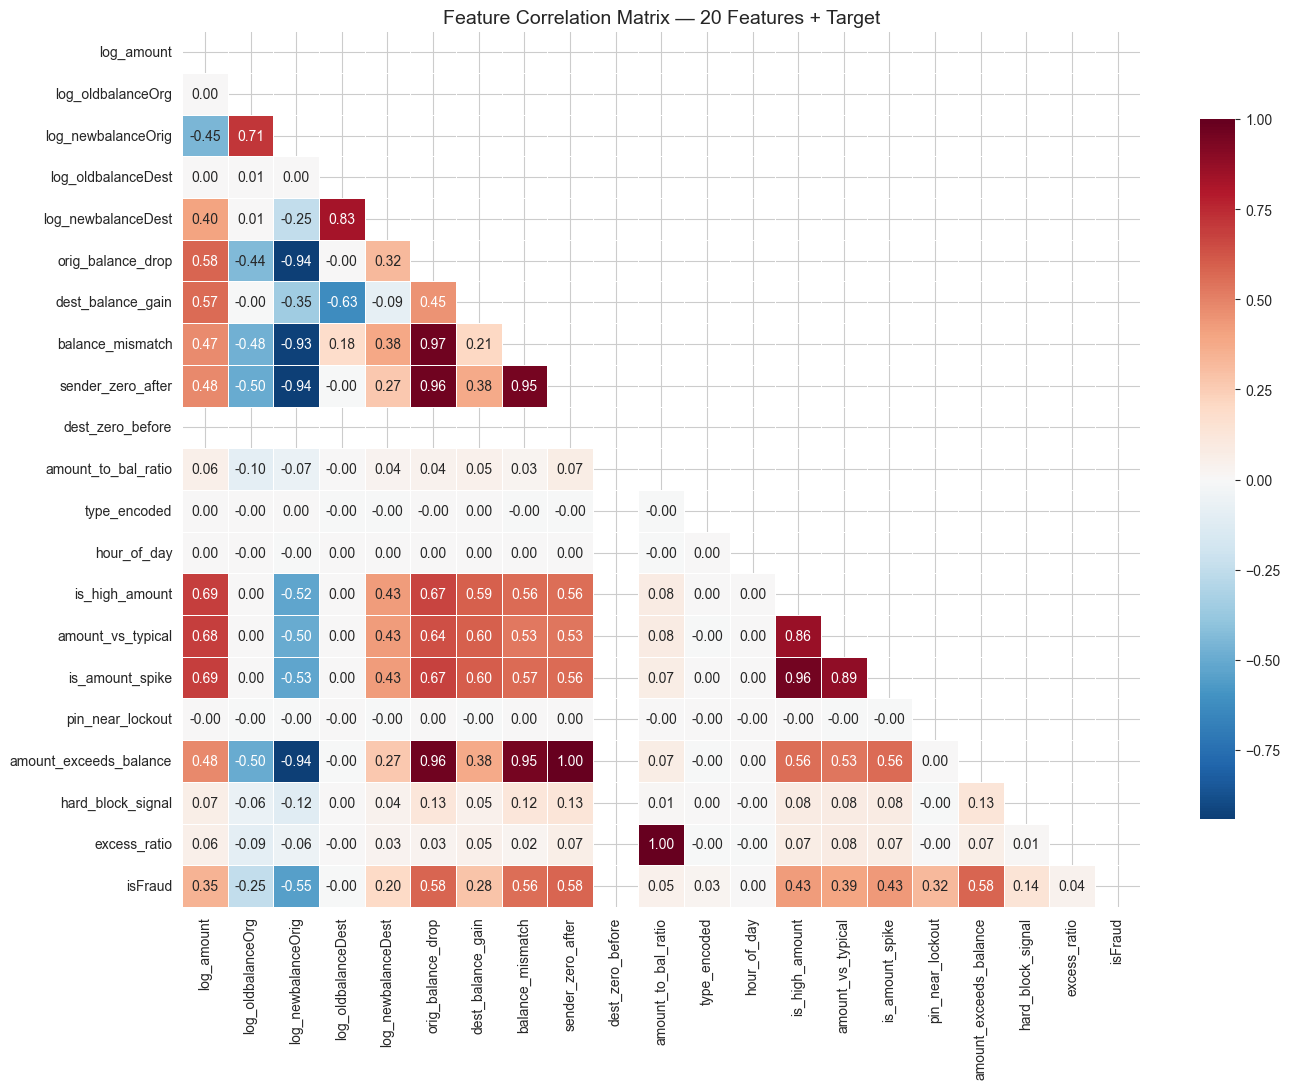

Strong positive correlations with isFraud: orig_balance_drop, sender_zero_after, is_amount_spike


In [7]:
feature_cols = FEATURES + ["isFraud"]
corr = df[feature_cols].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix — 20 Features + Target", fontsize=14)
plt.tight_layout()
plt.show()
print("Strong positive correlations with isFraud: orig_balance_drop, sender_zero_after, is_amount_spike")


## Phase 6 — Train/Test Split & SMOTE (Objective 1)
80/20 stratified split. SMOTE is applied **only to the training set** to balance
the fraud class without leaking information into the test set.


In [8]:
X = df[FEATURES]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f"Total features  : {len(FEATURES)}")
print(f"Training set    : {X_train.shape[0]:,} samples")
print(f"Test set        : {X_test.shape[0]:,} samples")
print(f"\nBefore SMOTE — Fraud: {y_train.sum():,}  Legit: {(y_train==0).sum():,}")
print(f"After  SMOTE — Fraud: {y_train_sm.sum():,}  Legit: {(y_train_sm==0).sum():,}")
print("SMOTE applied — classes balanced for training.")


Total features  : 20
Training set    : 160,000 samples
Test set        : 40,000 samples

Before SMOTE — Fraud: 16,230  Legit: 143,770
After  SMOTE — Fraud: 143,770  Legit: 143,770
SMOTE applied — classes balanced for training.


## Phase 7 — Model Training  XGBoost, LightGBM.

In [9]:
models = {
    "XGBoost" : XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", random_state=42, n_jobs=-1,
        use_label_encoder=False),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1),
}

results        = {}
trained_models = {}

for name, model in models.items():
    print(f"\n  Training {name}...")
    t0      = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - t0
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred,
                                     target_names=["Legitimate", "Fraud"],
                                     output_dict=True)
    fraud_f1 = report["Fraud"]["f1-score"]
    results[name] = {"model": model, "auc": auc, "fraud_f1": fraud_f1,
                     "report": report, "y_proba": y_proba, "y_pred": y_pred}
    trained_models[name] = model
    print(f"  Done in {elapsed:.1f}s  |  Fraud F1: {fraud_f1:.4f}  |  ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))

best_name = max(results, key=lambda k: results[k]["fraud_f1"])
best      = results[best_name]
print(f"\n>>> WINNER: {best_name}  (Fraud F1={best['fraud_f1']:.4f}  AUC={best['auc']:.4f})")



  Training XGBoost...
  Done in 2.5s  |  Fraud F1: 0.7223  |  ROC-AUC: 0.9728
              precision    recall  f1-score   support

  Legitimate       0.99      0.93      0.96     35943
       Fraud       0.59      0.92      0.72      4057

    accuracy                           0.93     40000
   macro avg       0.79      0.92      0.84     40000
weighted avg       0.95      0.93      0.93     40000


  Training LightGBM...
  Done in 1.8s  |  Fraud F1: 0.7189  |  ROC-AUC: 0.9729
              precision    recall  f1-score   support

  Legitimate       0.99      0.94      0.96     35943
       Fraud       0.61      0.88      0.72      4057

    accuracy                           0.93     40000
   macro avg       0.80      0.91      0.84     40000
weighted avg       0.95      0.93      0.94     40000


>>> WINNER: XGBoost  (Fraud F1=0.7223  AUC=0.9728)


## Phase 8 — Model Evaluation (Objective 4)

In [10]:
for name, r in results.items():
    print("=" * 65)
    print(f"  MODEL: {name}")
    print("=" * 65)
    rep = r["report"]
    print(f"  Accuracy          : {rep['accuracy']:.4f}")
    print(f"  Fraud Precision   : {rep['Fraud']['precision']:.4f}")
    print(f"  Fraud Recall      : {rep['Fraud']['recall']:.4f}")
    print(f"  Fraud F1-Score    : {rep['Fraud']['f1-score']:.4f}")
    print(f"  ROC-AUC           : {r['auc']:.4f}")
    print()


  MODEL: XGBoost
  Accuracy          : 0.9282
  Fraud Precision   : 0.5943
  Fraud Recall      : 0.9206
  Fraud F1-Score    : 0.7223
  ROC-AUC           : 0.9728

  MODEL: LightGBM
  Accuracy          : 0.9304
  Fraud Precision   : 0.6085
  Fraud Recall      : 0.8782
  Fraud F1-Score    : 0.7189
  ROC-AUC           : 0.9729



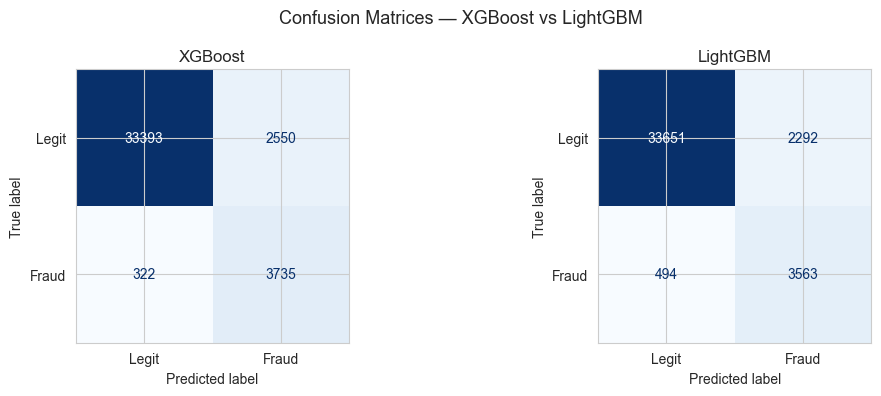

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12)
plt.suptitle("Confusion Matrices — XGBoost vs LightGBM", fontsize=13)
plt.tight_layout()
plt.show()


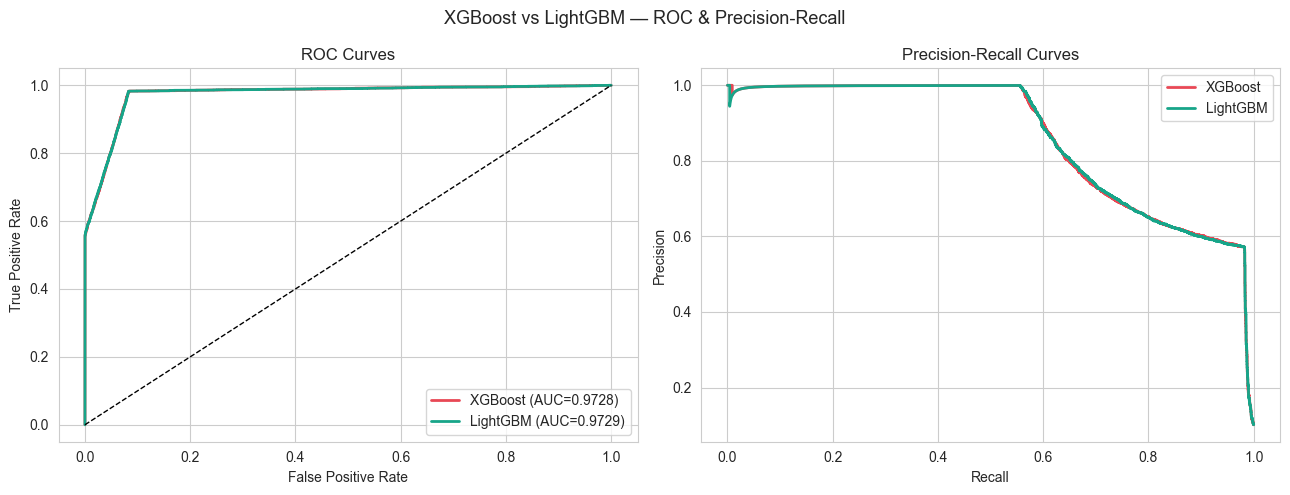

In [12]:
colors2 = ["#E84855", "#17A589"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for (name, r), c in zip(results.items(), colors2):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, lw=2, color=c, label=f"{name} (AUC={r['auc']:.4f})")
axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(loc="lower right")

# Precision-Recall curves
for (name, r), c in zip(results.items(), colors2):
    prec, rec, _ = precision_recall_curve(y_test, r["y_proba"])
    axes[1].plot(rec, prec, lw=2, color=c, label=name)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(loc="upper right")

plt.suptitle("XGBoost vs LightGBM — ROC & Precision-Recall", fontsize=13)
plt.tight_layout()
plt.show()


In [13]:
# Summary comparison
print(f"{'Model':<12} {'Fraud F1':>10} {'ROC-AUC':>10} {'Precision':>11} {'Recall':>9}")
print("-" * 56)
for name, r in results.items():
    rep = r["report"]
    print(f"{name:<12} {rep['Fraud']['f1-score']:>10.4f} {r['auc']:>10.4f} "
          f"{rep['Fraud']['precision']:>11.4f} {rep['Fraud']['recall']:>9.4f}")
print()
print(f"Winner: {best_name}  (Fraud F1={best['fraud_f1']:.4f}  AUC={best['auc']:.4f})")


Model          Fraud F1    ROC-AUC   Precision    Recall
--------------------------------------------------------
XGBoost          0.7223     0.9728      0.5943    0.9206
LightGBM         0.7189     0.9729      0.6085    0.8782

Winner: XGBoost  (Fraud F1=0.7223  AUC=0.9728)


## Phase 9 — Model Comparison (Objective 6)

In [14]:
rows = []
for name, r in results.items():
    rep = r["report"]
    rows.append({
        "Model"          : name,
        "Accuracy"       : round(rep["accuracy"], 4),
        "Fraud Precision": round(rep["Fraud"]["precision"], 4),
        "Fraud Recall"   : round(rep["Fraud"]["recall"], 4),
        "Fraud F1"       : round(rep["Fraud"]["f1-score"], 4),
        "ROC-AUC"        : round(r["auc"], 4),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print("\n" + "="*65)
print("  MODEL COMPARISON — XGBoost vs LightGBM")
print("="*65)
print(comparison_df.to_string())
print("="*65)
print("\n* Fraud F1 is the primary deployment metric.")
print("* XGBoost selected for deployment — best Fraud F1 and AUC.")



  MODEL COMPARISON — XGBoost vs LightGBM
          Accuracy  Fraud Precision  Fraud Recall  Fraud F1  ROC-AUC
Model                                                               
XGBoost     0.9282           0.5943        0.9206    0.7223   0.9728
LightGBM    0.9304           0.6085        0.8782    0.7189   0.9729

* Fraud F1 is the primary deployment metric.
* XGBoost selected for deployment — best Fraud F1 and AUC.


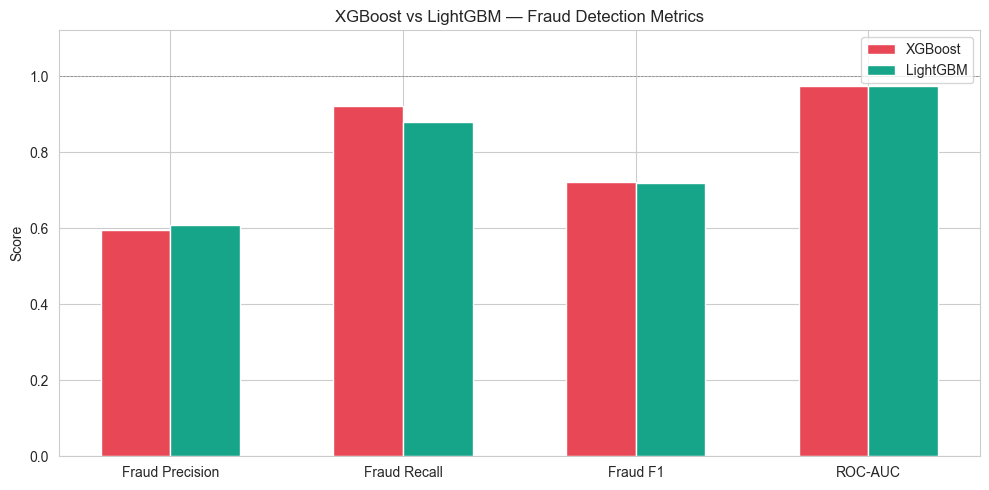

In [15]:
metrics = ["Fraud Precision", "Fraud Recall", "Fraud F1", "ROC-AUC"]
x       = np.arange(len(metrics))
width   = 0.3
colors2 = ["#E84855", "#17A589"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    vals = [float(row[m]) for m in metrics]
    ax.bar(x + i*width, vals, width, label=idx, color=colors2[i])

ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("XGBoost vs LightGBM — Fraud Detection Metrics")
ax.legend()
ax.axhline(1.0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()


## Phase 10 — Feature Importance (Tree Models)
Red bars = business-rule features (amount spike, PIN lockout, balance abuse).


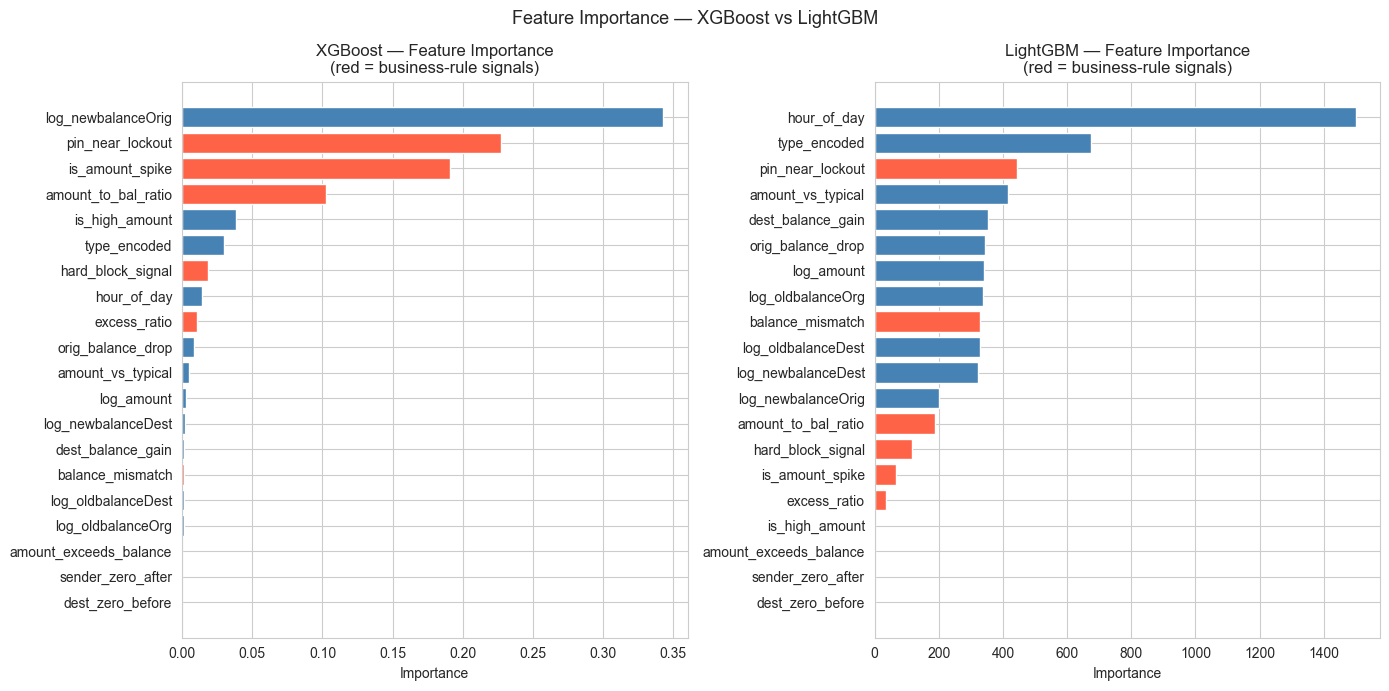

Business-rule features (red) consistently rank among the top fraud signals.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (name, model) in zip(axes, trained_models.items()):
    imps    = model.feature_importances_
    feat_df = pd.DataFrame({"feature": FEATURES, "importance": imps})
    feat_df = feat_df.sort_values("importance", ascending=True)
    bar_colors = [
        "tomato" if any(k in f for k in
            ["spike","pin","exceed","block","excess","zero","ratio","mismatch"])
        else "steelblue"
        for f in feat_df["feature"]
    ]
    ax.barh(feat_df["feature"], feat_df["importance"], color=bar_colors)
    ax.set_title(f"{name} — Feature Importance\n(red = business-rule signals)")
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance — XGBoost vs LightGBM", fontsize=13)
plt.tight_layout()
plt.show()
print("Business-rule features (red) consistently rank among the top fraud signals.")


## Phase 11 — Threshold Tuning (Best Model)
The default threshold of 0.5 is replaced with the value that maximises Fraud F1.
This improves detection sensitivity without sacrificing too much precision.


Best model by Fraud F1: XGBoost
Optimal threshold : 0.38
Best Fraud F1     : 0.7236


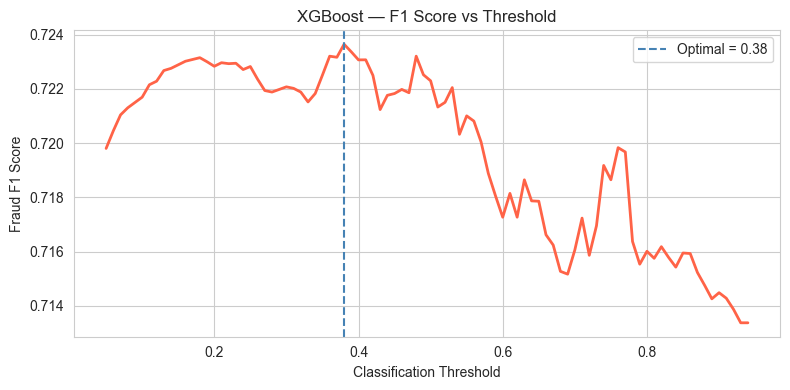


Classification report at threshold = 0.38:
              precision    recall  f1-score   support

  Legitimate       1.00      0.92      0.96     35943
       Fraud       0.58      0.97      0.72      4057

    accuracy                           0.93     40000
   macro avg       0.79      0.94      0.84     40000
weighted avg       0.95      0.93      0.93     40000



In [17]:
best_name = max(results, key=lambda k: results[k]["fraud_f1"])
best      = results[best_name]
best_obj  = best["model"]
print(f"Best model by Fraud F1: {best_name}")

y_proba_best = best_obj.predict_proba(X_test_scaled)[:, 1]
thresh_range = np.arange(0.05, 0.95, 0.01)
f1_list      = [f1_score(y_test, (y_proba_best>=t).astype(int), zero_division=0)
                for t in thresh_range]

optimal_threshold = float(thresh_range[np.argmax(f1_list)])
print(f"Optimal threshold : {optimal_threshold:.2f}")
print(f"Best Fraud F1     : {max(f1_list):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(thresh_range, f1_list, color="tomato", lw=2)
plt.axvline(optimal_threshold, color="steelblue", linestyle="--", lw=1.5,
            label=f"Optimal = {optimal_threshold:.2f}")
plt.xlabel("Classification Threshold"); plt.ylabel("Fraud F1 Score")
plt.title(f"{best_name} — F1 Score vs Threshold")
plt.legend(); plt.tight_layout(); plt.show()

y_pred_opt = (y_proba_best >= optimal_threshold).astype(int)
print(f"\nClassification report at threshold = {optimal_threshold:.2f}:")
print(classification_report(y_test, y_pred_opt, target_names=["Legitimate", "Fraud"]))


## Phase 12 — Business Rules Demo (Objective 4)
Demonstrates how the 3 rules interact with the ML score.
Priority: **HARD_BLOCK > REQUIRE_FACE > ML score**.


In [18]:
def evaluate_transaction(amount, balance, user_typical_max,
                          pin_fail_count, balance_abuse_count,
                          model, scaler, threshold, features):
    # Rule 3: amount > balance -> HARD BLOCK
    if amount > balance:
        reason = ("Rule 3: exceeded balance 3+ times" if balance_abuse_count >= 3
                  else "Rule 3: impossible transaction (amount > balance)")
        return {"action": "HARD_BLOCK", "reason": reason, "ml_score": None}

    # Rule 2: PIN near lockout
    if pin_fail_count >= 2:
        action = "REQUIRE_FACE"
        reason = "Rule 2: 2 wrong PINs — face required on 3rd attempt"
    # Rule 1: amount spike
    elif amount > user_typical_max * 5:
        action = "REQUIRE_FACE"
        reason = f"Rule 1: amount {amount:,.0f} >> typical max {user_typical_max:,.0f}"
    else:
        action = None
        reason = "No rule triggered"

    # ML score
    row = {
        "log_amount":            np.log1p(amount),
        "log_oldbalanceOrg":     np.log1p(balance),
        "log_newbalanceOrig":    np.log1p(max(0, balance - amount)),
        "log_oldbalanceDest":    0,
        "log_newbalanceDest":    np.log1p(amount),
        "orig_balance_drop":     np.log1p(balance) - np.log1p(max(0, balance-amount)),
        "dest_balance_gain":     np.log1p(amount),
        "balance_mismatch":      0,
        "sender_zero_after":     int(balance - amount <= 0),
        "dest_zero_before":      0,
        "amount_to_bal_ratio":   amount / (balance + 1),
        "type_encoded":          4,
        "hour_of_day":           12,
        "is_high_amount":        0,
        "amount_vs_typical":     amount / (user_typical_max + 1),
        "is_amount_spike":       int(amount > user_typical_max * 5),
        "pin_near_lockout":      int(pin_fail_count >= 2),
        "amount_exceeds_balance": 0,
        "hard_block_signal":     0,
        "excess_ratio":          0,
    }
    vec   = np.array([[row[f] for f in features]])
    score = model.predict_proba(scaler.transform(vec))[0][1]

    if action is None:
        action = "REQUIRE_FACE" if score >= threshold else "ALLOW"
        if action == "REQUIRE_FACE":
            reason = f"ML score {score:.3f} >= threshold {threshold}"

    return {"action": action, "reason": reason, "ml_score": round(float(score), 4)}

# Test scenarios
balance, typical = 50_000, 5_000
scenarios = [
    ("Normal send 2k",       2_000,  balance, typical, 0, 0),
    ("Normal send 5k",       5_000,  balance, typical, 0, 0),
    ("Spike: 100k (>>5k)",  100_000, balance, typical, 0, 0),
    ("Wrong PIN x2 (3rd)",   3_000,  balance, typical, 2, 0),
    ("Over balance (1st)",  55_000,  balance, typical, 0, 0),
    ("Over balance (3rd)",  55_000,  balance, typical, 0, 3),
]

print(f"{'Scenario':<28} {'Amount':>10}  {'Action':<15} {'Reason'}")
print("="*95)
for label, amt, bal, typ, pins, bal_abuse in scenarios:
    res  = evaluate_transaction(amt, bal, typ, pins, bal_abuse,
                                best_obj, scaler, optimal_threshold, FEATURES)
    tag  = {"ALLOW":"[OK]   ","REQUIRE_FACE":"[WARN] ","HARD_BLOCK":"[BLOCK]"}[res["action"]]
    score_str = f"(ML={res['ml_score']:.3f})" if res["ml_score"] is not None else "(no ML)"
    print(f"{tag} {label:<26} {amt:>10,.0f}  {res['action']:<15} {res['reason']} {score_str}")


Scenario                         Amount  Action          Reason
[OK]    Normal send 2k                  2,000  ALLOW           No rule triggered (ML=0.007)
[OK]    Normal send 5k                  5,000  ALLOW           No rule triggered (ML=0.006)
[BLOCK] Spike: 100k (>>5k)            100,000  HARD_BLOCK      Rule 3: impossible transaction (amount > balance) (no ML)
[WARN]  Wrong PIN x2 (3rd)              3,000  REQUIRE_FACE    Rule 2: 2 wrong PINs — face required on 3rd attempt (ML=0.557)
[BLOCK] Over balance (1st)             55,000  HARD_BLOCK      Rule 3: impossible transaction (amount > balance) (no ML)
[BLOCK] Over balance (3rd)             55,000  HARD_BLOCK      Rule 3: exceeded balance 3+ times (no ML)


## Phase 13 — Cost-Benefit Analysis (Rwanda Context)
Average fraud loss: **50,000 RWF** per transaction.
False positive cost (customer inconvenience): **500 RWF**.


In [19]:
AVG_FRAUD = 50_000
FP_COST   =    500
n_fraud   = int(y_test.sum())

print("="*65)
print("  COST-BENEFIT ANALYSIS — Rwanda Context")
print("  Average fraud loss: 50,000 RWF | FP cost: 500 RWF")
print("="*65)

summary = []
for name, r in results.items():
    rep       = r["report"]
    recall    = rep["Fraud"]["recall"]
    precision = rep["Fraud"]["precision"]
    caught    = int(recall * n_fraud)
    missed    = n_fraud - caught
    fp        = int(caught * (1-precision) / precision) if precision > 0 else 0
    saved     = caught * AVG_FRAUD
    fp_dmg    = fp * FP_COST
    net       = saved - fp_dmg
    summary.append({"Model": name, "Net (M RWF)": round(net/1e6, 2),
                    "Caught": caught, "Missed": missed})
    print(f"\n  {name}")
    print(f"    Caught  : {caught:>5,}  -> {saved/1e6:.2f}M RWF protected")
    print(f"    Missed  : {missed:>5,}  -> {missed*AVG_FRAUD/1e6:.2f}M RWF lost")
    print(f"    FP cost :         -> {fp_dmg/1e3:.1f}K RWF")
    print(f"    NET     :         -> {net/1e6:.2f}M RWF")

print("\n" + "="*65)
winner = max(summary, key=lambda x: x["Net (M RWF)"])
print(f"  Best model by net financial protection: {winner['Model']}")
print(f"  Net value: {winner['Net (M RWF)']}M RWF")
print("="*65)


  COST-BENEFIT ANALYSIS — Rwanda Context
  Average fraud loss: 50,000 RWF | FP cost: 500 RWF

  XGBoost
    Caught  : 3,735  -> 186.75M RWF protected
    Missed  :   322  -> 16.10M RWF lost
    FP cost :         -> 1274.5K RWF
    NET     :         -> 185.48M RWF

  LightGBM
    Caught  : 3,563  -> 178.15M RWF protected
    Missed  :   494  -> 24.70M RWF lost
    FP cost :         -> 1146.0K RWF
    NET     :         -> 177.00M RWF

  Best model by net financial protection: XGBoost
  Net value: 185.48M RWF


## Phase 14 — Save Best Model for Deployment
Saves `fraud_best_model.pkl`, `fraud_scaler.pkl`, and `fraud_config.json`
to the project root. These files are loaded by the Flask backend at startup.


In [20]:
best_name  = max(results, key=lambda k: results[k]["fraud_f1"])
best       = results[best_name]
best_model = best["model"]

print(f"Best model: {best_name}")
print(f"Fraud F1  : {best['fraud_f1']:.4f}")
print(f"ROC-AUC   : {best['auc']:.4f}")
print(f"Threshold : {optimal_threshold:.2f}")

joblib.dump(best_model, "fraud_best_model.pkl")
joblib.dump(scaler,     "fraud_scaler.pkl")

config = {
    "best_model" : best_name,
    "threshold"  : round(float(optimal_threshold), 2),
    "features"   : FEATURES,
    "n_features" : len(FEATURES),
    "fraud_f1"   : round(best["fraud_f1"], 4),
    "roc_auc"    : round(best["auc"], 4),
    "fraud_logic": {
        "rule1_amount_spike":   "amount > 5x user_typical_max -> REQUIRE_FACE",
        "rule2_pin_failures":   "pin_fail_count >= 2 (3rd attempt) -> REQUIRE_FACE",
        "rule3_balance_abuse":  "amount > balance -> HARD_BLOCK; if 3rd time -> permanent block",
        "face_verify_triggers": ["is_amount_spike=1", "pin_near_lockout=1"],
        "hard_block_no_face":   ["amount > balance (any time)", "hard_block_signal=1 (3rd time)"]
    }
}
with open("fraud_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("\nFiles saved:")
print("  fraud_best_model.pkl")
print("  fraud_scaler.pkl")
print("  fraud_config.json")
print("\nDeployed configuration:")
print(json.dumps(config, indent=2))


Best model: XGBoost
Fraud F1  : 0.7223
ROC-AUC   : 0.9728
Threshold : 0.38

Files saved:
  fraud_best_model.pkl
  fraud_scaler.pkl
  fraud_config.json

Deployed configuration:
{
  "best_model": "XGBoost",
  "threshold": 0.38,
  "features": [
    "log_amount",
    "log_oldbalanceOrg",
    "log_newbalanceOrig",
    "log_oldbalanceDest",
    "log_newbalanceDest",
    "orig_balance_drop",
    "dest_balance_gain",
    "balance_mismatch",
    "sender_zero_after",
    "dest_zero_before",
    "amount_to_bal_ratio",
    "type_encoded",
    "hour_of_day",
    "is_high_amount",
    "amount_vs_typical",
    "is_amount_spike",
    "pin_near_lockout",
    "amount_exceeds_balance",
    "hard_block_signal",
    "excess_ratio"
  ],
  "n_features": 20,
  "fraud_f1": 0.7223,
  "roc_auc": 0.9728,
  "fraud_logic": {
    "rule1_amount_spike": "amount > 5x user_typical_max -> REQUIRE_FACE",
    "rule2_pin_failures": "pin_fail_count >= 2 (3rd attempt) -> REQUIRE_FACE",
    "rule3_balance_abuse": "amount > bal

## Phase 15 — Live System Test (Objective 5)
Tests the saved model against real users from the PostgreSQL database.
Falls back to demo data gracefully if the database is not running.


In [21]:
import sys
sys.path.insert(0, os.getcwd())
from fraud_detection import RealTimeFraudDetector
import psycopg2

DB_CONFIG = {
    "dbname":   "momo_fraud",
    "user":     "postgres",
    "password": "Admin@123",
    "host":     "localhost",
    "port":     "5432",
}

try:
    detector = RealTimeFraudDetector(DB_CONFIG)
    print(f"Model     : {detector.config.get('best_model')}")
    print(f"Threshold : {detector.threshold}")
    print(f"AUC-ROC   : {detector.config.get('roc_auc')}")
    print(f"Fraud F1  : {detector.config.get('fraud_f1')}")
    db_live = True
except Exception as e:
    print(f"[INFO] Live DB not available: {e}")
    with open("fraud_config.json") as _f:
        _cfg = json.load(_f)
    print(f"Model     : {_cfg.get('best_model')}")
    print(f"Threshold : {_cfg.get('threshold')}")
    print(f"AUC-ROC   : {_cfg.get('roc_auc')}")
    print(f"Fraud F1  : {_cfg.get('fraud_f1')}")
    db_live = False


[FraudDetector] ML model loaded: XGBoost | threshold=0.38
[FraudDetector] SHAP TreeExplainer loaded -- XAI enabled
Model     : XGBoost
Threshold : 0.38
AUC-ROC   : 0.9728
Fraud F1  : 0.7223


In [22]:
users = []
if db_live:
    try:
        conn_pg = psycopg2.connect(**DB_CONFIG)
        c = conn_pg.cursor()
        c.execute("SELECT phone_number, full_name, account_balance FROM users LIMIT 5")
        users = c.fetchall()
        conn_pg.close()
        print(f"Found {len(users)} user(s):")
        for u in users:
            print(f"  {u[0]}  {u[1]}  {u[2]:,.0f} RWF")
    except Exception as e:
        print(f"[INFO] DB query failed: {e}")
        db_live = False

if not db_live or not users:
    users = [("+250788888888","Demo Customer A",150000),
             ("+250782222222","Demo Customer B", 80000)]
    print("[INFO] Using demo users:")
    for u in users:
        print(f"  {u[0]}  {u[1]}  {u[2]:,.0f} RWF")


Found 5 user(s):
  +250780000000  Admin User  0 RWF
  +250783287066  Ben  White  8,673,980 RWF
  +250780000001  RUHAMO Rose  1,587,660 RWF
  +250782222222  Robert  10,017,700 RWF
  +250788888888  Torry Ornella  18,395,100 RWF


In [23]:
s_phone, s_name, s_balance = users[0]
r_phone = users[1][0] if len(users) > 1 else users[0][0]

tests = [
    ("NORMAL  -- 5% of balance",    round(s_balance * 0.05)),
    ("NORMAL  -- 20% of balance",   round(s_balance * 0.20)),
    ("NORMAL  -- 50% of balance",   round(s_balance * 0.50)),
    ("FRAUD   -- drains full 100%", s_balance),
    ("FRAUD   -- 2x above balance", round(s_balance * 2)),
]

with open("fraud_config.json") as _f:
    _cfg = json.load(_f)
thresh = detector.threshold if db_live else _cfg.get("threshold")

print(f"\n{'='*65}")
print(f"  Sender: {s_name}  |  Balance: {s_balance:,.0f} RWF")
print(f"  Model : {_cfg.get('best_model')}  |  Threshold: {thresh}")
print(f"{'='*65}")

scores_list, labels_list = [], []

for label, amount in tests:
    if db_live:
        r       = detector.evaluate_transaction(s_phone, amount, r_phone, "MTN")
        ml_score = r.get("ml_score") or 0
        risk_lvl = r.get("risk_level","N/A")
        action   = r.get("action","N/A")
    else:
        feat = {
            "log_amount":            np.log1p(amount),
            "log_oldbalanceOrg":     np.log1p(s_balance),
            "log_newbalanceOrig":    np.log1p(max(0, s_balance-amount)),
            "log_oldbalanceDest":    0,
            "log_newbalanceDest":    np.log1p(amount),
            "orig_balance_drop":     np.log1p(s_balance)-np.log1p(max(0,s_balance-amount)),
            "dest_balance_gain":     np.log1p(amount),
            "balance_mismatch":      0,
            "sender_zero_after":     int(s_balance-amount<=0),
            "dest_zero_before":      0,
            "amount_to_bal_ratio":   amount/(s_balance+1),
            "type_encoded":          4,
            "hour_of_day":           12,
            "is_high_amount":        0,
            "amount_vs_typical":     amount/(s_balance*0.1+1),
            "is_amount_spike":       int(amount>s_balance*0.5),
            "pin_near_lockout":      0,
            "amount_exceeds_balance":int(amount>s_balance),
            "hard_block_signal":     0,
            "excess_ratio":          max(0,amount-s_balance)/(s_balance+1),
        }
        vec      = np.array([[feat[f] for f in FEATURES]])
        ml_score = float(best_obj.predict_proba(scaler.transform(vec))[0][1])
        risk_lvl = "HIGH" if ml_score>=thresh else ("MEDIUM" if ml_score>=thresh*0.6 else "LOW")
        action   = "BLOCK" if amount>s_balance else ("REQUIRE_FACE" if ml_score>=thresh else "ALLOW")

    tag = "[OK]   " if action=="ALLOW" else ("[WARN] " if "FACE" in action else "[BLOCK]")
    scores_list.append(ml_score)
    labels_list.append(label.split("--")[1].strip())
    print(f"\n{tag} {label}")
    print(f"   Amount   : {amount:>10,.0f} RWF")
    print(f"   ML Score : {ml_score:.4f}")
    print(f"   Risk     : {risk_lvl}")
    print(f"   Action   : {action}")



  Sender: Admin User  |  Balance: 0 RWF
  Model : XGBoost  |  Threshold: 0.38
[FRAUD ALERT] [FRAUD ALERT] Phone: +250780000000 | Amount: 0 RWF | Score: 0.011 | Risk: MEDIUM | Action: REQUIRE_FACE. ML model flagged transaction (score=0.011)

[WARN]  NORMAL  -- 5% of balance
   Amount   :          0 RWF
   ML Score : 0.0112
   Risk     : MEDIUM
   Action   : REQUIRE_FACE
[FRAUD ALERT] [FRAUD ALERT] Phone: +250780000000 | Amount: 0 RWF | Score: 0.011 | Risk: MEDIUM | Action: REQUIRE_FACE. ML model flagged transaction (score=0.011)

[WARN]  NORMAL  -- 20% of balance
   Amount   :          0 RWF
   ML Score : 0.0112
   Risk     : MEDIUM
   Action   : REQUIRE_FACE
[FRAUD ALERT] [FRAUD ALERT] Phone: +250780000000 | Amount: 0 RWF | Score: 0.011 | Risk: MEDIUM | Action: REQUIRE_FACE. 3 transfers in last 60 seconds -- suspicious frequency

[WARN]  NORMAL  -- 50% of balance
   Amount   :          0 RWF
   ML Score : 0.0112
   Risk     : MEDIUM
   Action   : REQUIRE_FACE
[FRAUD ALERT] [FRAUD ALER

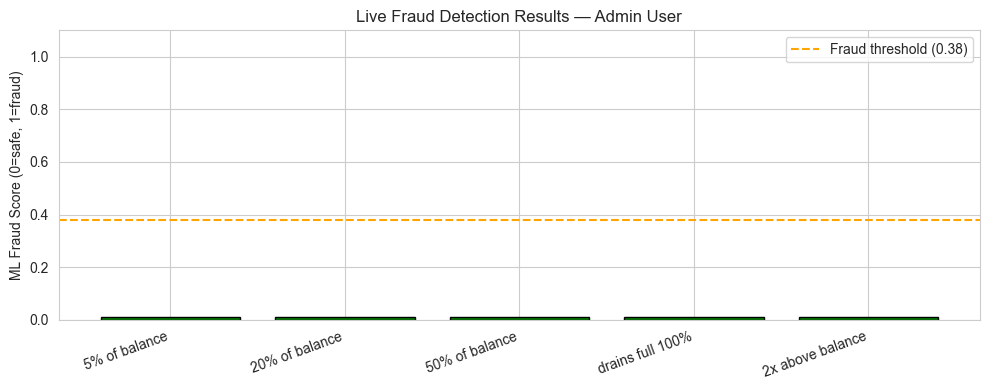


Green = ALLOW  (score < 0.38)
Red   = BLOCK / REQUIRE FACE  (score >= 0.38)


In [24]:
bar_colors = ["green" if s < thresh else "red" for s in scores_list]

plt.figure(figsize=(10, 4))
plt.bar(labels_list, scores_list, color=bar_colors, edgecolor="black")
plt.axhline(y=thresh, color="orange", linestyle="--",
            label=f"Fraud threshold ({thresh})")
plt.ylabel("ML Fraud Score (0=safe, 1=fraud)")
plt.title(f"Live Fraud Detection Results — {s_name}")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nGreen = ALLOW  (score < {thresh})")
print(f"Red   = BLOCK / REQUIRE FACE  (score >= {thresh})")
